# Visualisation for the Coarse Results

In [25]:
# Prerequisites 
import pandas as pd
import numpy as np
import os
import yaml
import json
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

def extract_metric(cell, metric):
    if isinstance(cell, dict):
        return cell.get(metric, None)
    try:
        d = ast.literal_eval(cell)
        return d.get(metric, None)
    except Exception:
        return None
    
def extract_metric_dict(cell):
    """Ensure the cell is a dictionary (convert from string if necessary)."""
    if isinstance(cell, dict):
        return cell
    try:
        return ast.literal_eval(cell)
    except Exception:
        return {}

def get_matching_df(df):
    """
    Given a DataFrame where the index and columns are scan IDs and each cell is a dictionary
    of metrics, return a new DataFrame containing only the diagonal cells.
    """
    diag_data = {}
    # Iterate over each scan in the index.
    for scan in df.index:
        if scan in df.columns:
            cell = df.loc[scan, scan]
            diag_data[scan] = extract_metric_dict(cell)
    # Create a new DataFrame from the nested dictionary.
    diag_df = pd.DataFrame.from_dict(diag_data, orient='index')
    return diag_df

## 1. Load dataframe

In [26]:
# Load config

# config = "/app/bindmount/gedi_data_real_scan/config_real_scan.yaml"
# config = "/app/bindmount/gedi_data_real_scan_5x315/config_real_scan_5x315.yaml"
# config = "/app/bindmount/gedi_data_4meters_scans/config_4meters.yaml"
# config = "/app/bindmount/gedi_data_2/config.yaml"
#config = "/app/bindmount/gedi_data_subset25x25_4m/config_subset25x25_4m.yaml"
# config = "/app/bindmount/gedi_data_subset25x50_4m/config_subset25x50_4m.yaml"
#config = "/app/bindmount/gedi_data_subset25x100_4m/config_subset25x100_4m.yaml"
#config = "/app/bindmount/test_set_30x30/config_30x30.yaml"
#config = "/app/bindmount/test_set_30x50/config_30x50.yaml"
config = "/app/bindmount/test_set_30x100/config_30x100.yaml"

with open(config, "r") as file:
        config = yaml.safe_load(file)

base = config["base"]
coarse_score_df = config["paths"]["results"]["filtering_coarse_overall"]
file_name = config["paths"]["results"]["filtering_coarse_overall_file_name"]

df_path = os.path.join(base, coarse_score_df, file_name)
coarse_score_df = pd.read_json(df_path)
print(df_path)
coarse_score_df

/app/bindmount/test_set_30x100/scans/filtering_coarse/overall_coarse.json


,763640,770066,771742,772764,772809,774135,774937,776548,776560,776572,...,8172410,8172412,8172414,8174397,8178944,8179592,8179609,8179627,8179631,8188922
771742,"{'score_sim1': 0.0998096579, 'score_sim2': 1.0...","{'score_sim1': 0.1213421347, 'score_sim2': 0.6...","{'score_sim1': 0.0094565586, 'score_sim2': 0.4...","{'score_sim1': 0.0320374858, 'score_sim2': 1.1...","{'score_sim1': 0.0530172031, 'score_sim2': 0.5...","{'score_sim1': 0.0520381757, 'score_sim2': 1.5...","{'score_sim1': 0.0387363716, 'score_sim2': 0.8...","{'score_sim1': 0.0798490724, 'score_sim2': 1.2...","{'score_sim1': 0.030909054000000002, 'score_si...","{'score_sim1': 0.08658769050000001, 'score_sim...",...,"{'score_sim1': 0.0181403285, 'score_sim2': 0.5...","{'score_sim1': 0.0290428957, 'score_sim2': 0.9...","{'score_sim1': 0.0291968747, 'score_sim2': 0.9...","{'score_sim1': 0.0547319789, 'score_sim2': 0.9...","{'score_sim1': 0.052724554, 'score_sim2': 1.10...","{'score_sim1': 0.12960514580000002, 'score_sim...","{'score_sim1': 0.055663200600000004, 'score_si...","{'score_sim1': 0.049196343100000005, 'score_si...","{'score_sim1': 0.072063863, 'score_sim2': 0.45...","{'score_sim1': 0.054916231, 'score_sim2': 0.94..."
774135,"{'score_sim1': 0.0906554594, 'score_sim2': 0.9...","{'score_sim1': 0.1481506183, 'score_sim2': 1.4...","{'score_sim1': 0.05497088, 'score_sim2': 1.501...","{'score_sim1': 0.0368270556, 'score_sim2': 0.5...","{'score_sim1': 0.07974801570000001, 'score_sim...","{'score_sim1': 0.0011946271, 'score_sim2': 0.1...","{'score_sim1': 0.014496431300000001, 'score_si...","{'score_sim1': 0.0689094034, 'score_sim2': 0.8...","{'score_sim1': 0.057753293600000005, 'score_si...","{'score_sim1': 0.1172890152, 'score_sim2': 1.0...",...,"{'score_sim1': 0.0578560796, 'score_sim2': 1.3...","{'score_sim1': 0.0401237417, 'score_sim2': 0.7...","{'score_sim1': 0.0402740017, 'score_sim2': 0.7...","{'score_sim1': 0.0049626225000000005, 'score_s...","{'score_sim1': 0.0039042998000000002, 'score_s...","{'score_sim1': 0.15646167730000002, 'score_sim...","{'score_sim1': 0.0928037844, 'score_sim2': 1.5...","{'score_sim1': 0.0040364597, 'score_sim2': 0.3...","{'score_sim1': 0.1060157525, 'score_sim2': 1.3...","{'score_sim1': 0.0056311856000000006, 'score_s..."
776548,"{'score_sim1': 0.0233843686, 'score_sim2': 0.1...","{'score_sim1': 0.0809484483, 'score_sim2': 0.9...","{'score_sim1': 0.0885307783, 'score_sim2': 1.5...","{'score_sim1': 0.047088479700000005, 'score_si...","{'score_sim1': 0.0523993934, 'score_sim2': 0.7...","{'score_sim1': 0.06800548220000001, 'score_sim...","{'score_sim1': 0.0706951747, 'score_sim2': 1.4...","{'score_sim1': 0.0007748527, 'score_sim2': 0.0...","{'score_sim1': 0.07258481160000001, 'score_sim...","{'score_sim1': 0.050017924400000004, 'score_si...",...,"{'score_sim1': 0.0767950184, 'score_sim2': 1.2...","{'score_sim1': 0.0502371691, 'score_sim2': 0.7...","{'score_sim1': 0.0500828715, 'score_sim2': 0.7...","{'score_sim1': 0.0729064933, 'score_sim2': 1.6...","{'score_sim1': 0.0718481706, 'score_sim2': 1.4...","{'score_sim1': 0.0892114593, 'score_sim2': 0.8...","{'score_sim1': 0.0710532792, 'score_sim2': 1.0...","{'score_sim1': 0.0675298251, 'score_sim2': 1.0...","{'score_sim1': 0.0525687293, 'score_sim2': 0.8...","{'score_sim1': 0.0735750565, 'score_sim2': 1.8..."
776560,"{'score_sim1': 0.0940613093, 'score_sim2': 0.9...","{'score_sim1': 0.0987553016, 'score_sim2': 0.5...","{'score_sim1': 0.027658687600000002, 'score_si...","{'score_sim1': 0.0261645779, 'score_sim2': 1.0...","{'score_sim1': 0.030352699, 'score_sim2': 0.32...","{'score_sim1': 0.0492381021, 'score_sim2': 1.5...","{'score_sim1': 0.039041420800000004, 'score_si...","{'score_sim1': 0.0740151002, 'score_sim2': 1.1...","{'score_sim1': 0.0083579769, 'score_sim2': 0.2...","{'score_sim1': 0.09358029820000001, 'score_sim...",...,"{'score_sim1': 0.0092963859, 'score_sim2': 0.4...","{'score_sim1': 0.0230158885, 'score_sim2': 0.8...","{'score_sim1': 0.023170186000000002, 'score_si...","{'sc

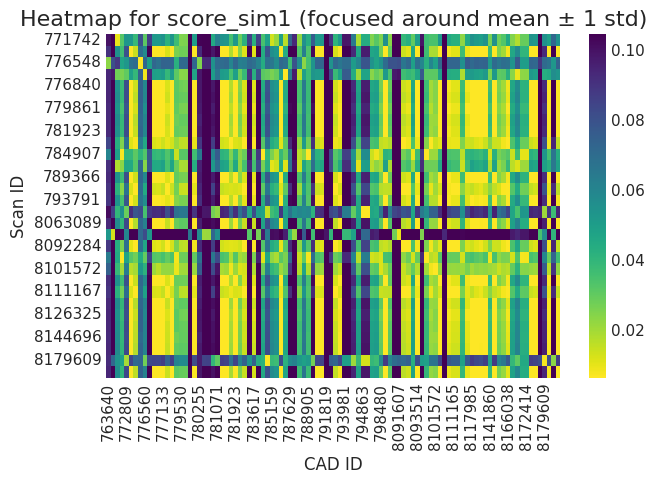

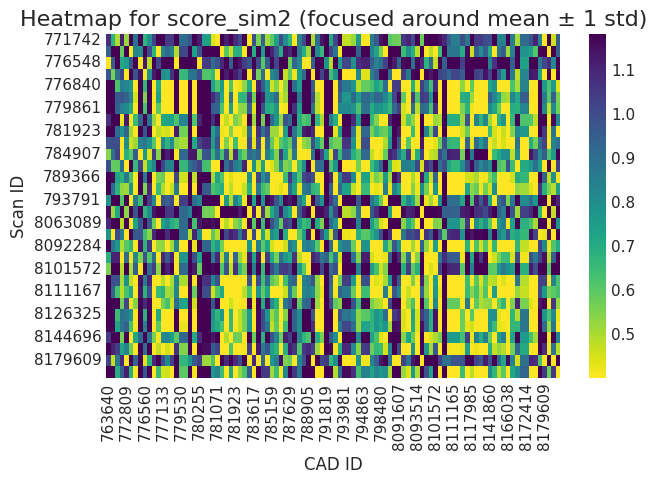

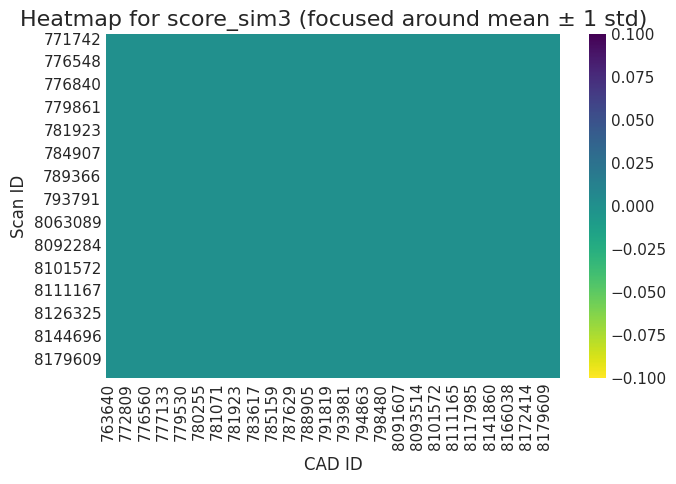

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

def extract_metric(cell, metric):
    if cell is None:
        return None
    if isinstance(cell, dict):
        return cell.get(metric, None)
    try:
        d = ast.literal_eval(cell)
        return d.get(metric, None)
    except Exception:
        return None

def plot_heatmap(df_metric, title, focus_factor=1.0, figsize=(7, 5), cmap="viridis_r", output_file=None):
    # Compute global mean and std from all values in the DataFrame.
    global_mean = df_metric.stack().mean()
    global_std = df_metric.stack().std()
    # Focus the color scale around the mean.
    vmin = global_mean - focus_factor * global_std
    vmax = global_mean + focus_factor * global_std

    plt.figure(figsize=figsize)
    sns.heatmap(df_metric, annot=False, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title, fontsize=16)
    plt.xlabel("CAD ID", fontsize=12)
    plt.ylabel("Scan ID", fontsize=12)
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Heatmap saved to {output_file}")
    plt.show()

# Assuming coarse_score_df is your loaded DataFrame, where cells are dictionaries.
df_sim1 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim1"))
df_sim2 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim2"))
df_sim3 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim3"))

plot_heatmap(df_sim1, "Heatmap for score_sim1 (focused around mean ± 1 std)", focus_factor=1.0)
plot_heatmap(df_sim2, "Heatmap for score_sim2 (focused around mean ± 1 std)", focus_factor=1.0)
plot_heatmap(df_sim3, "Heatmap for score_sim3 (focused around mean ± 1 std)", focus_factor=1.0)

### 1.1 Describe all the scores
No matter if it's a match or no, we take all the scores

In [28]:
# Assume 'coarse_score_df' is your original DataFrame with scan IDs as index 
# and CAD IDs as columns, each cell being a dict with keys like "score_sim1", etc.
# Extract and stack the metrics into Series, then create a new DataFrame.
df_sim1 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim1")).stack().reset_index(drop=True)
df_sim2 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim2")).stack().reset_index(drop=True)
# df_sim3 = coarse_score_df.applymap(lambda cell: extract_metric(cell, "score_sim3")).stack().reset_index(drop=True)

df_metrics = pd.DataFrame({
    "score_sim1": df_sim1,
    "score_sim2": df_sim2,
    # "score_sim3": df_sim3
})

# THIS IS THE SCORES DATAFRAME
# SCORE STATS
df_metrics.describe()

,score_sim1,score_sim2
count,3000.000000,3000.000000
mean,0.055420,0.791169
std,0.049155,0.390836
min,0.000059,0.003672
25%,0.014120,0.476844
50%,0.041373,0.770070
75%,0.087515,1.056204
max,0.229028,1.942075


### 1.2 Describe the scores of the matching scans
This is the metrics of the coarse filtering, but only when there is a match. 

Here what we want it the minimum std, and also a certain kind of consistency (max score as close as possible of the mean)

In [29]:
# Extract the diagonal values (the "match" for each scan)
matching_score_df = get_matching_df(coarse_score_df)
desc = matching_score_df.describe()
desc.loc["95%"] = matching_score_df.quantile(0.95)
desc.loc["99%"] = matching_score_df.quantile(0.99)
desc

,score_sim1,score_sim2,score_sim3
count,30.000000,30.000000,30.0
mean,0.002999,0.182469,0.0
std,0.003444,0.137416,0.0
min,0.000059,0.003672,0.0
25%,0.000718,0.073566,0.0
50%,0.001439,0.151285,0.0
75%,0.003778,0.267555,0.0
max,0.013578,0.532717,0.0
95%,0.009442,0.441142,0.0
99%,0.012383,0.522659,0.0


## Rank analysis

### Load the data
This is the rank we evaluate here **not the scores of the ranks**

In [30]:
folder = config["paths"]["results"]["filtering_coarse_rank"]
file = config["paths"]["results"]["filtering_coarse_rank_file_name"]


df_path = os.path.join(base, folder, file)
coarse_rank_df = pd.read_json(df_path)
coarse_rank_df

,score_sim1,score_sim2
771742,1,11
774135,1,2
776548,1,1
776560,2,7
776840,3,12
777133,1,1
779861,3,1
781282,2,2
781923,6,3
782185,1,3


In [31]:
desc = coarse_rank_df.describe()
desc.loc["95%"] = coarse_rank_df.quantile(0.95)
desc.loc["99%"] = coarse_rank_df.quantile(0.99)
desc

,score_sim1,score_sim2
count,30.000000,30.000000
mean,2.333333,6.633333
std,1.561019,7.175069
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,2.500000
75%,3.000000,11.750000
max,6.000000,25.000000
95%,5.000000,21.550000
99%,5.710000,24.130000


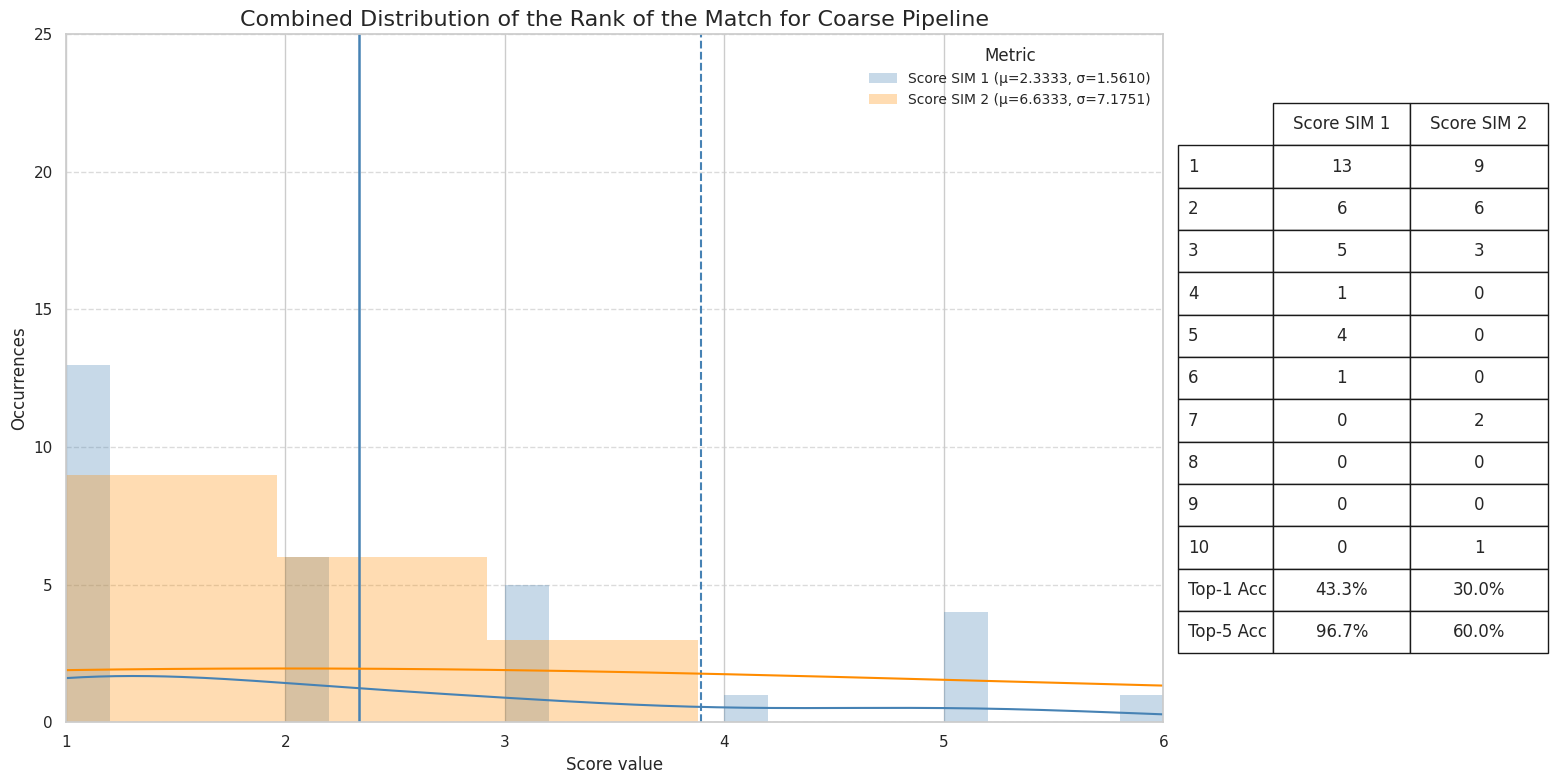

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the seaborn-whitegrid theme for a clean look.
sns.set_theme(style="whitegrid")

# Define the metrics, display titles, and colors.
metrics = ["score_sim1", "score_sim2"]
titles = ["Score SIM 1", "Score SIM 2"]
colors = ["steelblue", "darkorange"]

# Create a figure and main axis.
fig, ax = plt.subplots(figsize=(14, 8))

# Loop over each metric to plot its distribution.
for metric, label, color in zip(metrics, titles, colors):
    # Get the metric data (ensure numeric values).
    data = coarse_rank_df[metric].dropna().astype(float)
    m = data.mean()
    s = data.std()
    
    # Plot histogram with KDE overlay.
    sns.histplot(data, bins=25, stat="count", color=color, alpha=0.3, kde=True, linewidth=0, ax=ax,
                 label=f"{label} (μ={m:.4f}, σ={s:.4f})")
    
    # Add vertical lines for mean and ± standard deviation.
    ax.axvline(m, color=color, linestyle='-', linewidth=1.8)
    ax.axvline(m - s, color=color, linestyle='--', linewidth=1.5)
    ax.axvline(m + s, color=color, linestyle='--', linewidth=1.5)

# Final plot styling for the main plot.
ax.set_title("Combined Distribution of the Rank of the Match for Coarse Pipeline", fontsize=16)
ax.set_xlabel("Score value", fontsize=12)
ax.set_ylabel("Occurrences", fontsize=12)
ax.set_xlim(1, 6)
ax.set_ylim(0, 25)
ax.legend(title="Metric", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# -------------------------
# Create a summary table of frequency counts.
# For each metric, count the occurrence of each integer rank between 1 and 10.
bins_range = range(1, 11)
summary_data = {}
for metric, title in zip(metrics, titles):
    freq = coarse_rank_df[metric].dropna().astype(float).value_counts().sort_index()
    # Ensure each integer value between 1 and 10 has a count (defaulting to 0)
    counts = [freq.get(b, 0) for b in bins_range]
    summary_data[title] = counts

summary_table = pd.DataFrame(summary_data, index=list(bins_range))

# -------------------------
# Compute Top-1 and Top-5 accuracy and append to the summary table
accuracy_data = {}
for metric, title in zip(metrics, titles):
    vals = coarse_rank_df[metric].dropna().astype(float)
    total = len(vals)
    top1 = (vals == 1).sum() / total
    top5 = (vals <= 5).sum() / total
    # store as percentage
    accuracy_data[title] = [f"{top1:.1%}", f"{top5:.1%}"]

# build a small DataFrame and concatenate
acc_df = pd.DataFrame(
    accuracy_data,
    index=["Top-1 Acc", "Top-5 Acc"]
)
summary_table = pd.concat([summary_table, acc_df])

# -------------------------
# then re-draw your table with the new summary_table
table = ax.table(
    cellText=summary_table.values,
    rowLabels=summary_table.index,
    colLabels=summary_table.columns,
    cellLoc='center',
    loc='center left',
    bbox=[1.1, 0.1, 0.25, 0.8]
)

# Adjust layout so that the main plot doesn't overlap with the table.
plt.subplots_adjust(right=0.70)
plt.tight_layout()

# Display the plot.
plt.show()

In [33]:
import ast

def get_matching_df(df):
    diag_values = {}
    for scan in df.index:
        if scan in df.columns:
            cell = df.loc[scan, scan]
            diag_values[scan] = {
                "score_sim1": extract_metric(cell, "score_sim1"),
                "score_sim2": extract_metric(cell, "score_sim2"),
                "score_sim3": extract_metric(cell, "score_sim3")
            }
    return pd.DataFrame.from_dict(diag_values, orient="index")

This snippets is good to determine the threshold to use 

/tmp/ipykernel_3284/75863956.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/tmp/ipykernel_3284/75863956.py:36: MatplotlibDeprecationWarning: Passing the emit parameter of set_xlim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  plt.xlim(0, 0,3)
/tmp/ipykernel_3284/75863956.py:36: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(0, 0,3)


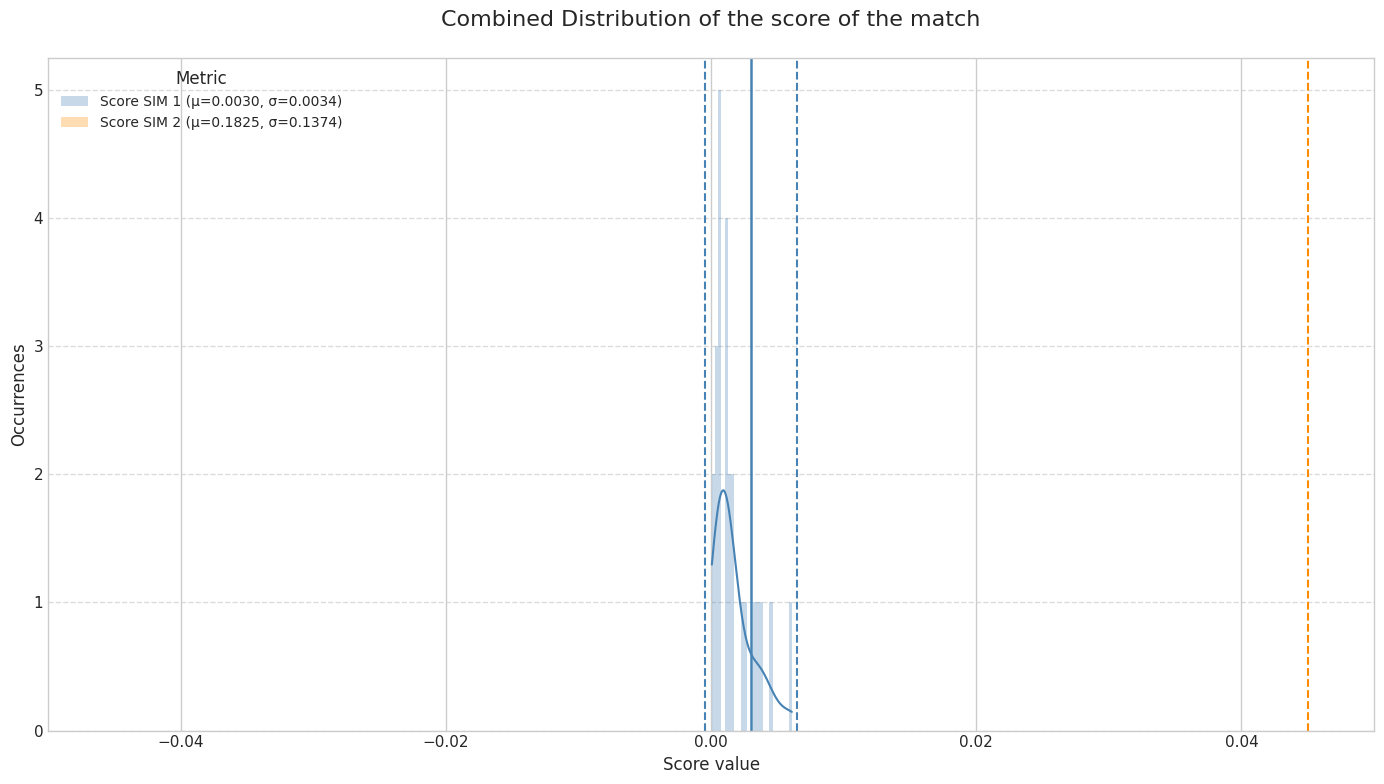

In [34]:
# Set the seaborn-whitegrid theme
plt.style.use('seaborn-whitegrid')

# Define the metrics, display titles, and colors
metrics = ["score_sim1", "score_sim2"]
titles = ["Score SIM 1", "Score SIM 2"]
colors = ["steelblue", "darkorange", "mediumseagreen"]

# Create a single figure and axis
plt.figure(figsize=(14, 8))

# Loop over each metric to plot its distribution
for metric, label, color in zip(metrics, titles, colors):
    # Get the metric data from the DataFrame
    data = matching_score_df[metric]
    m = data.mean()
    s = data.std()
    # Filter data within [mean - std, mean + std]
    filtered = data[(data >= m - s) & (data <= m + s)]
    
    # Plot histogram with KDE overlay (filled, translucent)
    sns.histplot(filtered, bins=25, kde=True, stat="count",
                 label=f"{label} (μ={m:.4f}, σ={s:.4f})",
                 color=color, fill=True, alpha=0.3, linewidth=0)
    
    # Add vertical lines for the mean and ± standard deviation
    plt.axvline(m, color=color, linestyle='-', linewidth=1.8)
    plt.axvline(m - s, color=color, linestyle='--', linewidth=1.5)
    plt.axvline(m + s, color=color, linestyle='--', linewidth=1.5)

# Final plot styling
plt.title("Combined Distribution of the score of the match\n", fontsize=16)
plt.xlabel("Score value", fontsize=12)
plt.ylabel("Occurrences", fontsize=12)
# Optionally, adjust x-axis limits based on your data; for example:
plt.xlim(0, 0,3)
plt.legend(title="Metric", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()